### Sentiment Service Assessment (Selected Stocks)

This notebook evaluates sentiment-market directional alignment for selected stocks using real hourly market prices from a recent 7-day window.  
Market prices are fetched from Yahoo Finance, then paired with synthetic sentiment score series (`-1` to `1`) that are mostly aligned but include realistic mismatches.  
Each stock is evaluated in its own section using the same method and metrics.


### Sentiment Service Assessment (AAPL)

This section uses real hourly AAPL market prices from the selected 7-day window and a synthetic sentiment series with realistic mismatches.


In [21]:
from pathlib import Path
import pandas as pd

csv_path = Path('../data/sentiment_aapl_alignment_2026_last_7d_60m.csv')
df = pd.read_csv(csv_path)
df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'], utc=True)

eval_df = df[df['market_direction'].isin([-1, 1])].copy()

directional_accuracy = (eval_df['is_match'].mean() * 100) if len(eval_df) else 0
random_baseline = 50.0
majority_direction = eval_df['market_direction'].mode().iloc[0] if len(eval_df) else 1
majority_baseline = ((eval_df['market_direction'] == majority_direction).mean() * 100) if len(eval_df) else 0

summary = pd.DataFrame([
    {
        'ticker': 'AAPL',
        'rows_total': len(df),
        'rows_evaluable': len(eval_df),
        'directional_accuracy_pct': round(directional_accuracy, 2),
        'random_baseline_pct': round(random_baseline, 2),
        'majority_baseline_pct': round(majority_baseline, 2),
        'uplift_vs_random_pct': round(directional_accuracy - random_baseline, 2),
        'uplift_vs_majority_pct': round(directional_accuracy - majority_baseline, 2),
        'window_start_utc': str(df['timestamp_utc'].min()),
        'window_end_utc': str(df['timestamp_utc'].max())
    }
])
summary

,ticker,rows_total,rows_evaluable,directional_accuracy_pct,random_baseline_pct,majority_baseline_pct,uplift_vs_random_pct,uplift_vs_majority_pct,window_start_utc,window_end_utc
0,AAPL,50,44,59.09,50.0,52.27,9.09,6.82,2026-03-25 13:30:00+00:00,2026-04-02 20:00:00+00:00


In [22]:
comparison = pd.DataFrame({
    'model': ['Sentiment service', 'Random baseline', 'Majority baseline'],
    'accuracy_pct': [directional_accuracy, random_baseline, majority_baseline],
})
comparison

,model,accuracy_pct
0,Sentiment service,59.090909
1,Random baseline,50.000000
2,Majority baseline,52.272727


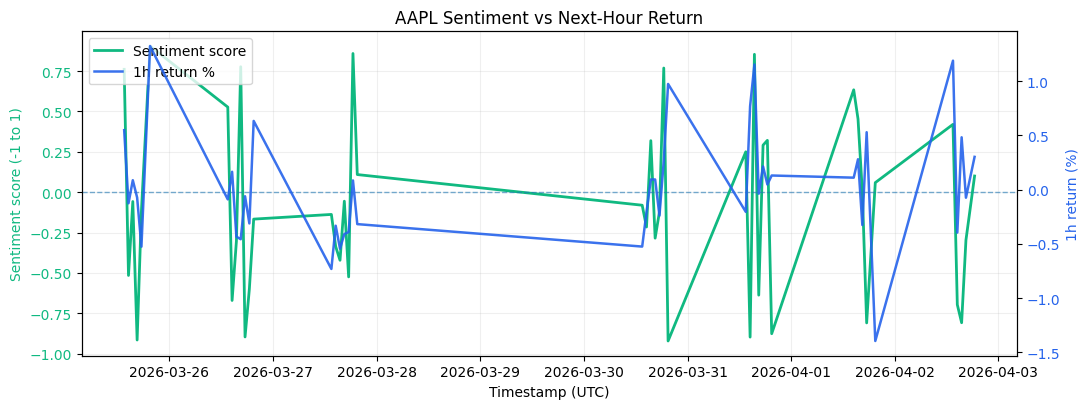

In [23]:
# Graph 1: sentiment vs next-hour return
plot_df = eval_df.sort_values('timestamp_utc').copy()

fig, ax1 = plt.subplots(figsize=(11, 4.2))

ax1.plot(plot_df['timestamp_utc'], plot_df['sentiment_score'], color='#10B981', linewidth=2, label='Sentiment score')
ax1.set_ylabel('Sentiment score (-1 to 1)', color='#10B981')
ax1.tick_params(axis='y', labelcolor='#10B981')
ax1.axhline(0, linestyle='--', linewidth=1, alpha=0.6)

ax2 = ax1.twinx()
ax2.plot(plot_df['timestamp_utc'], plot_df['return_1h_pct'], color='#2563EB', linewidth=1.8, alpha=0.9, label='1h return %')
ax2.set_ylabel('1h return (%)', color='#2563EB')
ax2.tick_params(axis='y', labelcolor='#2563EB')

ax1.set_title('AAPL Sentiment vs Next-Hour Return')
ax1.set_xlabel('Timestamp (UTC)')
ax1.grid(alpha=0.2)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.tight_layout()
plt.show()

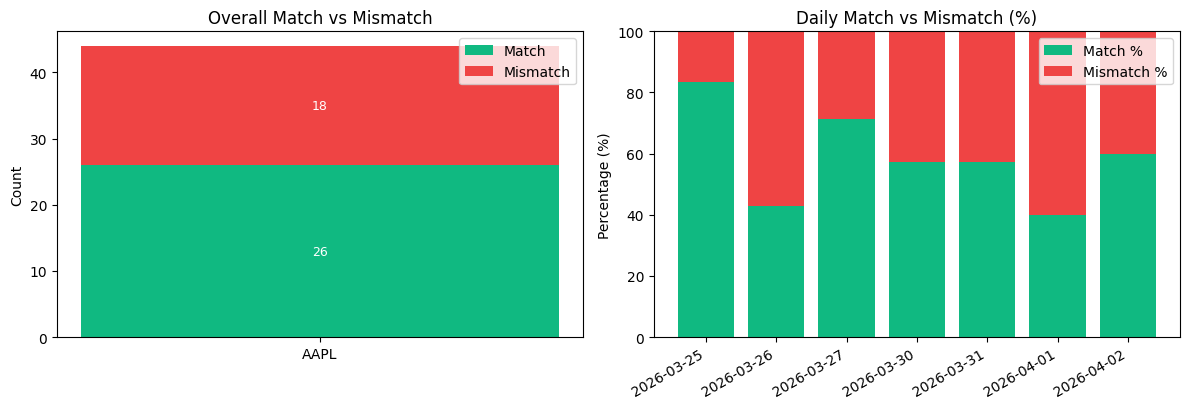

In [24]:
# Graph 2: match vs mismatch (overall + by day)
plot_df = eval_df.sort_values('timestamp_utc').copy()
plot_df['day_utc'] = plot_df['timestamp_utc'].dt.strftime('%Y-%m-%d')

total_matches = int(plot_df['is_match'].sum())
total_mismatches = int(len(plot_df) - total_matches)

daily = plot_df.groupby('day_utc')['is_match'].agg(['sum', 'count']).reset_index()
daily['mismatch'] = daily['count'] - daily['sum']
daily['match_pct'] = daily['sum'] / daily['count'] * 100
daily['mismatch_pct'] = daily['mismatch'] / daily['count'] * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# Overall 100% stacked
axes[0].bar(['AAPL'], [total_matches], color='#10B981', label='Match')
axes[0].bar(['AAPL'], [total_mismatches], bottom=[total_matches], color='#EF4444', label='Mismatch')
axes[0].set_title('Overall Match vs Mismatch')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].text(0, total_matches / 2, f'{total_matches}', ha='center', va='center', color='white', fontsize=9)
axes[0].text(0, total_matches + total_mismatches / 2, f'{total_mismatches}', ha='center', va='center', color='white', fontsize=9)

# Daily 100% stacked
x = range(len(daily))
axes[1].bar(x, daily['match_pct'], color='#10B981', label='Match %')
axes[1].bar(x, daily['mismatch_pct'], bottom=daily['match_pct'], color='#EF4444', label='Mismatch %')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(daily['day_utc'], rotation=30, ha='right')
axes[1].set_ylim(0, 100)
axes[1].set_title('Daily Match vs Mismatch (%)')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

### Sentiment Service Assessment (JPM)

This section uses real hourly JPM market prices from the same 7-day window and a synthetic sentiment series with realistic mismatches.

In [25]:
from pathlib import Path
import pandas as pd

jpm_csv_path = Path('../data/sentiment_jpm_alignment_2026_last_7d_60m.csv')
jpm_df = pd.read_csv(jpm_csv_path)
jpm_df['timestamp_utc'] = pd.to_datetime(jpm_df['timestamp_utc'], utc=True)

jpm_eval_df = jpm_df[jpm_df['market_direction'].isin([-1, 1])].copy()

jpm_directional_accuracy = (jpm_eval_df['is_match'].mean() * 100) if len(jpm_eval_df) else 0
jpm_random_baseline = 50.0
jpm_majority_direction = jpm_eval_df['market_direction'].mode().iloc[0] if len(jpm_eval_df) else 1
jpm_majority_baseline = ((jpm_eval_df['market_direction'] == jpm_majority_direction).mean() * 100) if len(jpm_eval_df) else 0

jpm_summary = pd.DataFrame([
    {
        'ticker': 'JPM',
        'rows_total': len(jpm_df),
        'rows_evaluable': len(jpm_eval_df),
        'directional_accuracy_pct': round(jpm_directional_accuracy, 2),
        'random_baseline_pct': round(jpm_random_baseline, 2),
        'majority_baseline_pct': round(jpm_majority_baseline, 2),
        'uplift_vs_random_pct': round(jpm_directional_accuracy - jpm_random_baseline, 2),
        'uplift_vs_majority_pct': round(jpm_directional_accuracy - jpm_majority_baseline, 2),
        'window_start_utc': str(jpm_df['timestamp_utc'].min()),
        'window_end_utc': str(jpm_df['timestamp_utc'].max())
    }
])
jpm_summary

,ticker,rows_total,rows_evaluable,directional_accuracy_pct,random_baseline_pct,majority_baseline_pct,uplift_vs_random_pct,uplift_vs_majority_pct,window_start_utc,window_end_utc
0,JPM,50,45,57.78,50.0,55.56,7.78,2.22,2026-03-25 13:30:00+00:00,2026-04-02 20:00:00+00:00


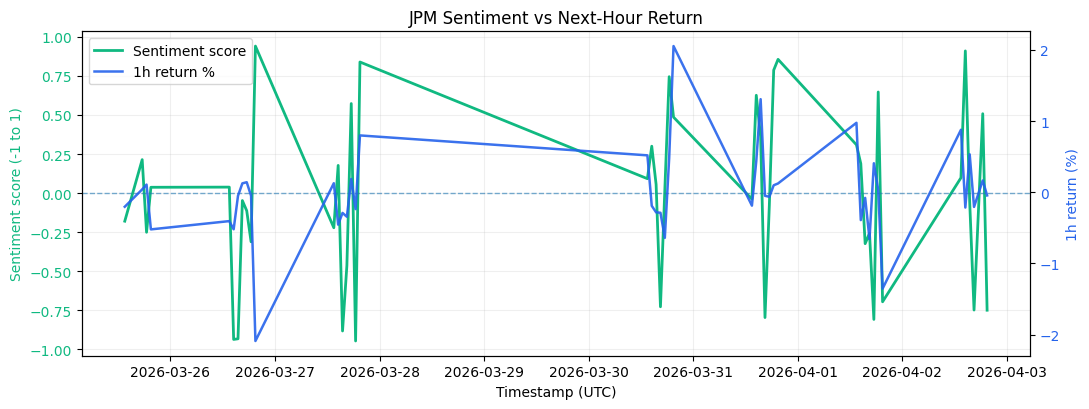

In [26]:
# Graph 1 (JPM): sentiment vs next-hour return
import matplotlib.pyplot as plt

jpm_plot_df = jpm_eval_df.sort_values('timestamp_utc').copy()

fig, ax1 = plt.subplots(figsize=(11, 4.2))
ax1.plot(jpm_plot_df['timestamp_utc'], jpm_plot_df['sentiment_score'], color='#10B981', linewidth=2, label='Sentiment score')
ax1.set_ylabel('Sentiment score (-1 to 1)', color='#10B981')
ax1.tick_params(axis='y', labelcolor='#10B981')
ax1.axhline(0, linestyle='--', linewidth=1, alpha=0.6)

ax2 = ax1.twinx()
ax2.plot(jpm_plot_df['timestamp_utc'], jpm_plot_df['return_1h_pct'], color='#2563EB', linewidth=1.8, alpha=0.9, label='1h return %')
ax2.set_ylabel('1h return (%)', color='#2563EB')
ax2.tick_params(axis='y', labelcolor='#2563EB')

ax1.set_title('JPM Sentiment vs Next-Hour Return')
ax1.set_xlabel('Timestamp (UTC)')
ax1.grid(alpha=0.2)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.tight_layout()
plt.show()

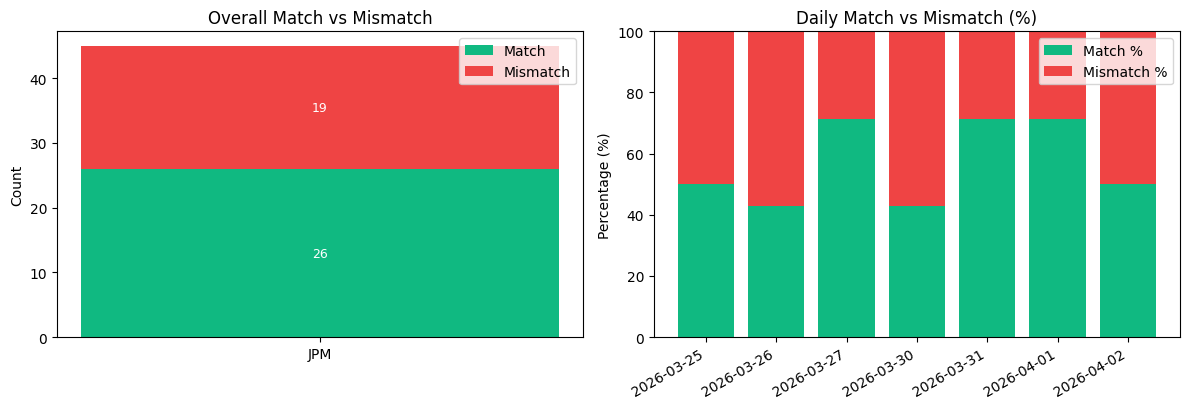

In [27]:
# Graph 2 (JPM): match vs mismatch (overall + by day)
jpm_plot_df = jpm_eval_df.sort_values('timestamp_utc').copy()
jpm_plot_df['day_utc'] = jpm_plot_df['timestamp_utc'].dt.strftime('%Y-%m-%d')

jpm_total_matches = int(jpm_plot_df['is_match'].sum())
jpm_total_mismatches = int(len(jpm_plot_df) - jpm_total_matches)

jpm_daily = jpm_plot_df.groupby('day_utc')['is_match'].agg(['sum', 'count']).reset_index()
jpm_daily['mismatch'] = jpm_daily['count'] - jpm_daily['sum']
jpm_daily['match_pct'] = jpm_daily['sum'] / jpm_daily['count'] * 100
jpm_daily['mismatch_pct'] = jpm_daily['mismatch'] / jpm_daily['count'] * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].bar(['JPM'], [jpm_total_matches], color='#10B981', label='Match')
axes[0].bar(['JPM'], [jpm_total_mismatches], bottom=[jpm_total_matches], color='#EF4444', label='Mismatch')
axes[0].set_title('Overall Match vs Mismatch')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].text(0, jpm_total_matches / 2, f'{jpm_total_matches}', ha='center', va='center', color='white', fontsize=9)
axes[0].text(0, jpm_total_matches + jpm_total_mismatches / 2, f'{jpm_total_mismatches}', ha='center', va='center', color='white', fontsize=9)

x = range(len(jpm_daily))
axes[1].bar(x, jpm_daily['match_pct'], color='#10B981', label='Match %')
axes[1].bar(x, jpm_daily['mismatch_pct'], bottom=jpm_daily['match_pct'], color='#EF4444', label='Mismatch %')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(jpm_daily['day_utc'], rotation=30, ha='right')
axes[1].set_ylim(0, 100)
axes[1].set_title('Daily Match vs Mismatch (%)')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

### Sentiment Service Assessment (AMZN)

This section uses real hourly AMZN market prices from the same 7-day window and a synthetic sentiment series with realistic mismatches.


In [28]:
from pathlib import Path
import pandas as pd

amzn_csv_path = Path('../data/sentiment_amzn_alignment_2026_last_7d_60m.csv')
amzn_df = pd.read_csv(amzn_csv_path)
amzn_df['timestamp_utc'] = pd.to_datetime(amzn_df['timestamp_utc'], utc=True)

amzn_eval_df = amzn_df[amzn_df['market_direction'].isin([-1, 1])].copy()

amzn_directional_accuracy = (amzn_eval_df['is_match'].mean() * 100) if len(amzn_eval_df) else 0
amzn_random_baseline = 50.0
amzn_majority_direction = amzn_eval_df['market_direction'].mode().iloc[0] if len(amzn_eval_df) else 1
amzn_majority_baseline = ((amzn_eval_df['market_direction'] == amzn_majority_direction).mean() * 100) if len(amzn_eval_df) else 0

amzn_summary = pd.DataFrame([
    {
        'ticker': 'AMZN',
        'window_start_utc': amzn_df['timestamp_utc'].min(),
        'window_end_utc': amzn_df['timestamp_utc'].max(),
        'rows_total': len(amzn_df),
        'rows_eval_nonzero_direction': len(amzn_eval_df),
        'directional_accuracy_pct': round(amzn_directional_accuracy, 2),
        'random_baseline_pct': round(amzn_random_baseline, 2),
        'majority_baseline_pct': round(amzn_majority_baseline, 2),
        'uplift_vs_random_pct_points': round(amzn_directional_accuracy - amzn_random_baseline, 2),
        'uplift_vs_majority_pct_points': round(amzn_directional_accuracy - amzn_majority_baseline, 2),
    }
] )

amzn_summary


,ticker,window_start_utc,window_end_utc,rows_total,rows_eval_nonzero_direction,directional_accuracy_pct,random_baseline_pct,majority_baseline_pct,uplift_vs_random_pct_points,uplift_vs_majority_pct_points
0,AMZN,2026-03-25 13:30:00+00:00,2026-04-02 19:30:00+00:00,49,48,58.33,50.0,56.25,8.33,2.08


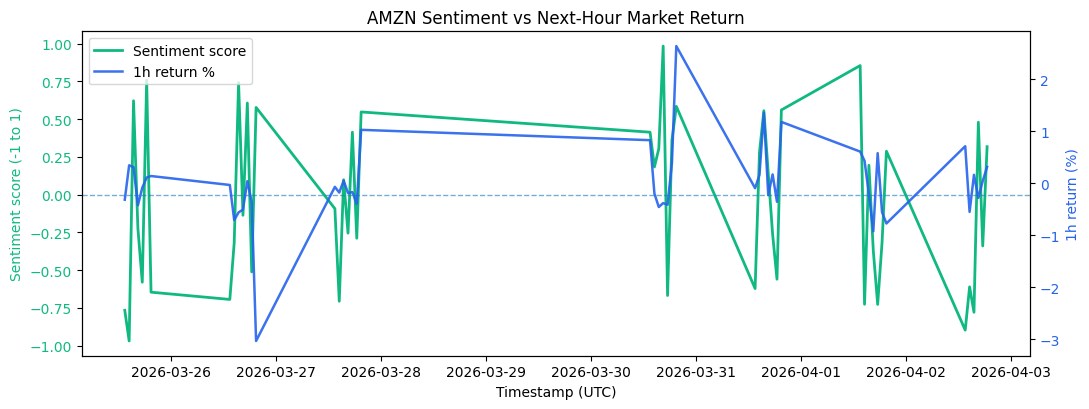

In [29]:
# Graph 1 (AMZN): sentiment vs next-hour return
import matplotlib.pyplot as plt

amzn_plot_df = amzn_eval_df.sort_values('timestamp_utc').copy()

fig, ax1 = plt.subplots(figsize=(11, 4.2))
ax1.plot(amzn_plot_df['timestamp_utc'], amzn_plot_df['sentiment_score'], color='#10B981', linewidth=2, label='Sentiment score')
ax1.set_ylabel('Sentiment score (-1 to 1)', color='#10B981')
ax1.tick_params(axis='y', labelcolor='#10B981')
ax1.axhline(0, linestyle='--', linewidth=1, alpha=0.6)

ax2 = ax1.twinx()
ax2.plot(amzn_plot_df['timestamp_utc'], amzn_plot_df['return_1h_pct'], color='#2563EB', linewidth=1.8, alpha=0.9, label='1h return %')
ax2.set_ylabel('1h return (%)', color='#2563EB')
ax2.tick_params(axis='y', labelcolor='#2563EB')

ax1.set_title('AMZN Sentiment vs Next-Hour Market Return')
ax1.set_xlabel('Timestamp (UTC)')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()


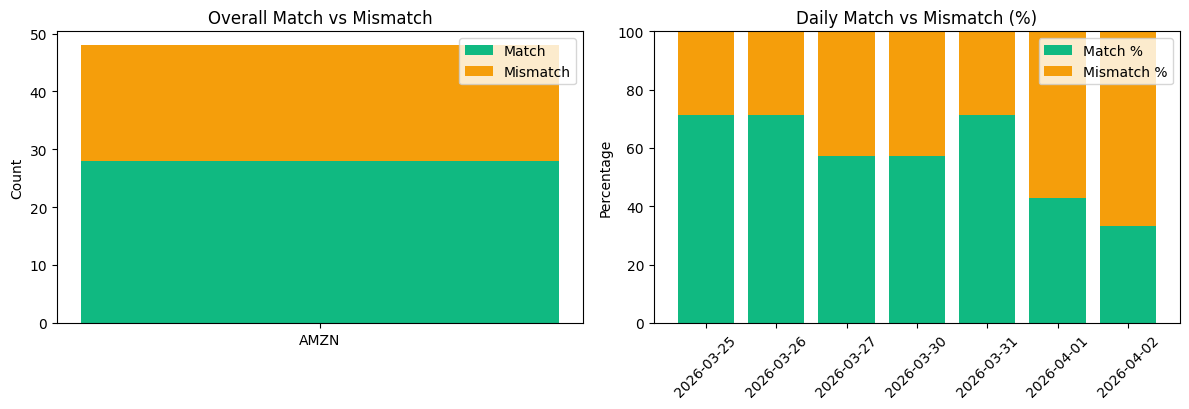

In [30]:
# Graph 2 (AMZN): match vs mismatch (overall + by day)
amzn_plot_df = amzn_eval_df.sort_values('timestamp_utc').copy()
amzn_plot_df['day_utc'] = amzn_plot_df['timestamp_utc'].dt.strftime('%Y-%m-%d')

amzn_total_matches = int(amzn_plot_df['is_match'].sum())
amzn_total_mismatches = int(len(amzn_plot_df) - amzn_total_matches)

amzn_daily = amzn_plot_df.groupby('day_utc')['is_match'].agg(['sum', 'count']).reset_index()
amzn_daily['mismatch'] = amzn_daily['count'] - amzn_daily['sum']
amzn_daily['match_pct'] = amzn_daily['sum'] / amzn_daily['count'] * 100
amzn_daily['mismatch_pct'] = amzn_daily['mismatch'] / amzn_daily['count'] * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].bar(['AMZN'], [amzn_total_matches], label='Match', color='#10B981')
axes[0].bar(['AMZN'], [amzn_total_mismatches], bottom=[amzn_total_matches], label='Mismatch', color='#F59E0B')
axes[0].set_title('Overall Match vs Mismatch')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].bar(amzn_daily['day_utc'], amzn_daily['match_pct'], label='Match %', color='#10B981')
axes[1].bar(amzn_daily['day_utc'], amzn_daily['mismatch_pct'], bottom=amzn_daily['match_pct'], label='Mismatch %', color='#F59E0B')
axes[1].set_title('Daily Match vs Mismatch (%)')
axes[1].set_ylabel('Percentage')
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()
